In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Dense

In [3]:
!which python

/Users/harshraj/Desktop/Deep-Learning/venv/bin/python


In [5]:
df = pd.read_csv('/Users/harshraj/Desktop/Deep-Learning/Datasets/Churn_Modelling.csv')

# Preprocessing

In [6]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [7]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [10]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [11]:
def transform(data):
    if data == True:
        return 1
    else:
        return 0

In [12]:
df['Geography_Germany'] = df['Geography_Germany'].apply(transform)
df['Geography_Spain'] = df['Geography_Spain'].apply(transform)
df['Gender_Male'] = df['Gender_Male'].apply(transform)

In [13]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [14]:
X = df.drop('Exited',axis=1)
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

# Training

In [ ]:
model = Sequential()
#  "Sequential" means layers are stacked one after another — output of one layer feeds into the next.
# Adding the first hidden layer with 11 neurons and sigmoid activation function, and specifying the input dimension as 11 (number of features).
model.add(Dense(11,activation='sigmoid',input_dim=11))
# no input_dim needed (Keras infers it from the previous layer)
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

/Users/harshraj/Desktop/Deep-Learning/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

# Algorithm that updates weights. Adam (Adaptive Moment Estimation) combines momentum + RMSProp — adapts learning rate per parameter

In [ ]:
history = model.fit(X_train_trf,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)
# Instead of updating weights after seeing all 8000 training samples (batch GD) or after each single sample (SGD), the model updates weights after every 50 samples. This is mini-batch gradient descent — a good balance between speed and stable convergence.
# verbose = 1 means we get a progress bar for each epoch. validation_split=0.2 means 20% of the training data is used for validation during training.

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7934 - loss: 0.4850 - val_accuracy: 0.7987 - val_loss: 0.4587
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.7934 - loss: 0.4578 - val_accuracy: 0.7987 - val_loss: 0.4352
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.7953 - loss: 0.4407 - val_accuracy: 0.8125 - val_loss: 0.4239
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.8092 - loss: 0.4338 - val_accuracy: 0.8213 - val_loss: 0.4199
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - accuracy: 0.8106 - loss: 0.4306 - val_accuracy: 0.8213 - val_loss: 0.4180
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.8109 - loss: 0.4290 - val_accuracy: 0.8225 - val_loss: 0.4166
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - accuracy: 0.8120 - loss: 0.4274 - val_accuracy: 0.8263 - val_loss: 0.4152
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.8170 - loss: 0.4

In [25]:
y_pred = model.predict(X_test)
y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step


array([[0.06440906],
       [0.20765762],
       [0.20765762],
       ...,
       [0.20765762],
       [0.20765762],
       [0.06440906]], shape=(2000, 1), dtype=float32)

In [26]:
y_pred = y_pred.argmax(axis=-1)
accuracy_score(y_test,y_pred)

0.8035

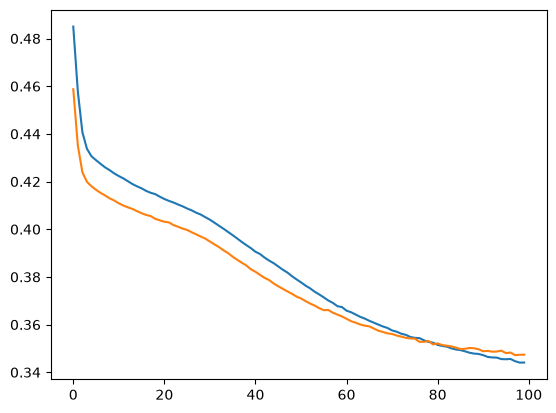

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

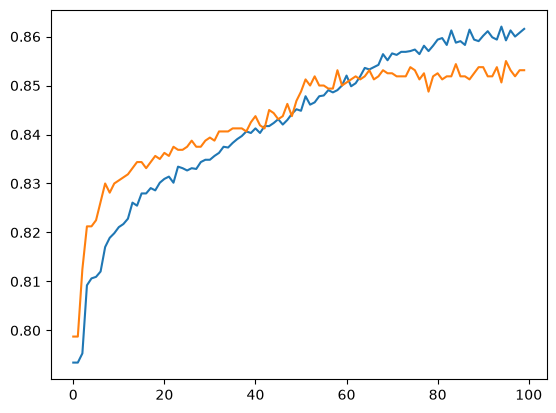

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])